In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

In [14]:
random = pd.read_csv("./baseline_random.txt", delimiter=':', header=None, names=["instance", "energy"])

In [15]:
dqn_greedy = pd.read_csv("./dqnflat_SingleSLMEnvParallel1D_DoubleDQN_2025-04-01_22-46-31.pt_greedy_0-1_3_10.txt", 
                         delimiter=':', header=None, names=["instance", "energy"])
dqn_epsilon10 = pd.read_csv("./dqnflat_SingleSLMEnvParallel1D_DoubleDQN_2025-04-01_22-46-31.pt_epsilon_0-1_10_10.txt", 
                         delimiter=':', header=None, names=["instance", "energy"])
dqn_epsilon3 = pd.read_csv("./dqnflat_SingleSLMEnvParallel1D_DoubleDQN_2025-04-01_22-46-31.pt_epsilon_0-1_3_10.txt", 
                         delimiter=':', header=None, names=["instance", "energy"])

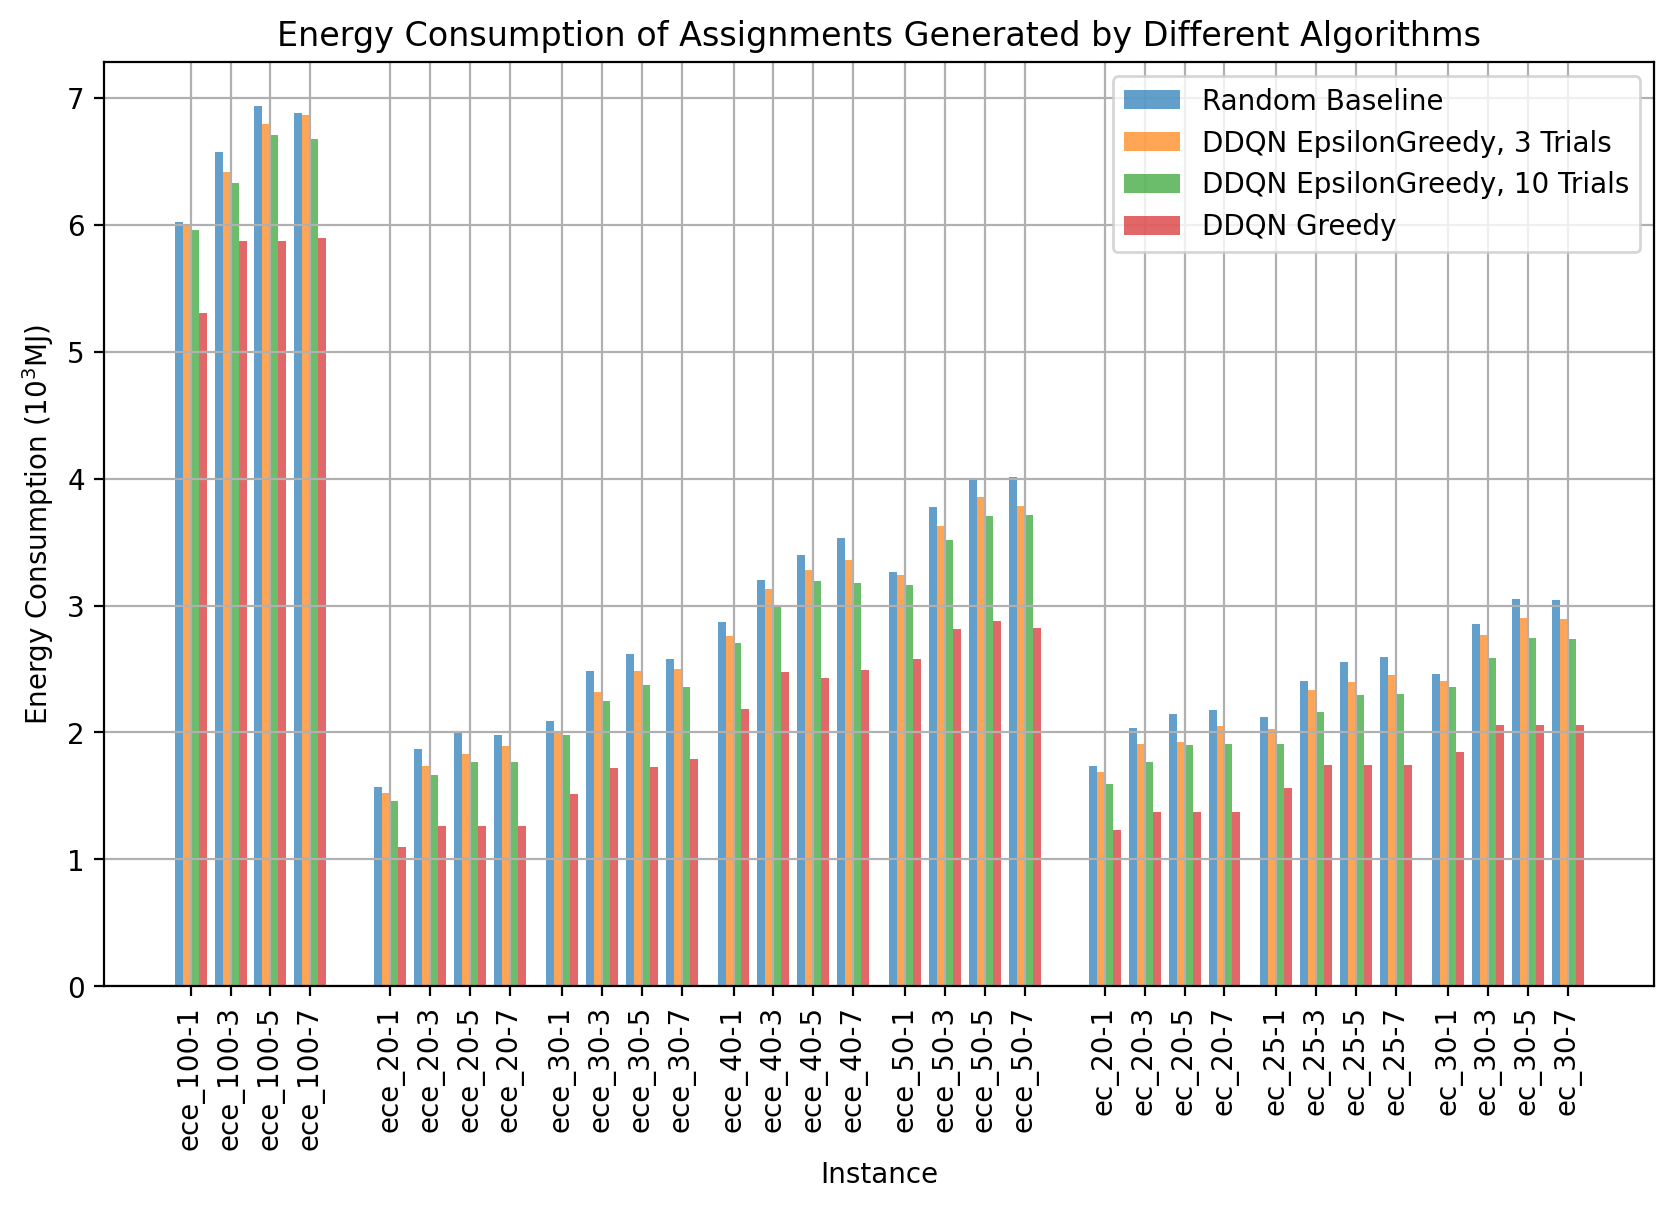

In [41]:
plt.figure(figsize=(10, 6), dpi=200)

bar_width=0.2
x = np.arange(len(random["instance"])).astype(float)
x[4:] += 1
x[-12:] += 1
x[8:] += 0.3
x[12:] += 0.3
x[16:] += 0.3
x[-8:] += 0.3
x[-4:] += 0.3

plt.bar(x-1.5*bar_width, random["energy"], label="Random Baseline", width=bar_width, alpha=0.7)
plt.bar(x-0.5*bar_width, dqn_epsilon3["energy"], label="DDQN EpsilonGreedy, 3 Trials", width=bar_width, alpha=0.7)
plt.bar(x+0.5*bar_width, dqn_epsilon10["energy"], label="DDQN EpsilonGreedy, 10 Trials", width=bar_width, alpha=0.7)
plt.bar(x+1.5*bar_width, dqn_greedy["energy"], label="DDQN Greedy", width=bar_width, alpha=0.7)

plt.xticks(x, random["instance"].map(lambda x:x.split('.')[0]), rotation=90);
plt.legend()

plt.xlabel("Instance")
plt.ylabel(r"Energy Consumption ($10^3$MJ)")
plt.title("Energy Consumption of Assignments Generated by Different Algorithms")
plt.grid()